Для решения задачи использовал ансамбль бустингов, так как он хорошо ищет нелинейные связи и работает с категориями. Провел Разведовательный анализ данных. Основываясь на нем сделал Feature Engineering. Сделал Кросс Валидацию, чтобы вручную подобрать гиперпараметры и найти лучший порог. В конце проанализировал данные на графике Shap и проверил возникшие гипотезы.
Feature Engineering:
    Убрал имя, фамилию так как на FeatureImportance они давали очень низкие показатели и их отсутсвие никак не повлияло на метрику
    Заменил не особо важный признак кабины, на более глобальные, которые дают модели более точное понимание категорий к которым относится пассажир
    Обработал пропуски: в Age взял медиану по планете, в Расходах поставил 0, потому что если нет расходов значит там скорее всего ничего и не тратили
    Создал новый признак TotalSpend, который обобщает покупательную способность пассажира
    Также заметил что на палубе "T" всего 5 человек, поэтому просто приклеил их к "A", чтобы модель не думала что палуба T серьезный признак
    Заметил что пассажиры которые не тратили деньги гораздно чаще становятся Транспортированными), и сделал признак isZeroSpend, чтобы модели было легче учитывать таких пассажиров

Выводы после анализа:
1. Люди в криосне гораздно чаще попадают в аномалию
2. Дети гораздо чаще попадают в аномалии
3. Люди с каютой на правом борте(S) попадают в аномалию гораздно чаще чем с каютой на левом(P)
4. Люди у которых родная планета Europa попадают в аномалии чаще, а люди с Earth реже
5. Люди летящие на 55 Cancri e чаще попадают в аномалию
6. Больше пострадали блоки: B_S, C_S. Слабо: A_P, A_S, E_P, E_S, G_S. Не пострадали: G_P
8. Блок C самый богатый, блоки E, G самые бедные и многочисленные
9. На правой палубе(S), было больше людей в криосне
10. Люди с Europa гораздно больше денег тратят в фудкорте (и поэтому пропадают)
11. Земляне меньше пользуются криосном, поэтому в аномалию их попало меньше
12. В блоках A,B,C летят только жители Europa, Марсиане в основном живут в F, а земляне в G
13. Жители планеты Europe чаще пользуются криосном
    
Подтвержденные Гипотезы:
1. Люди которые были в криосне попадали в аномалию независимо от их расположения на корабле! Единственные блоки на корабле в которых не пропали почти все люди в криосне это G и E
2. Люди которые тратили больше денег на шопинг и фудкорт чаще попадали в аномалию, люди которые предпочитали тратить деньги на СПА, ВР и домашний сервес попадали гораздо реже
3. Жители планеты Earth самые бедные, жители Europe самые богатые
4. Все кто пользовался криосном для поездки на 55 Cancri e пропали

Вывод:
    Аномалия перенесла всех пассажиров на корабле находящихся в криосне, кроме бедных людей в самом хвосте. Столкновение произошло с Правым бортом из-за чего пассажиры часто предпочитающии развлечения вне своей каюты и дети(которые не могли оценить опастность) попали под дейтсвие аномалии. Больше всего пострадали богатые жители планеты Europe. Возможно именно большое количество людей находящихся одновременно в криосне на правой палубе притянуло аномалию.
    
Рекомендуемые решения:
1. Распределять пассажиров в зависимости от их намерений использовать Криосон в полете.
2. Не делать четких разделений блоков по классам.
3. Порекомендовать людям активно посещающим шопинг и фудкорт использовать маячки, которые помогут найти их в случае катастрофы.
4. Проводить инструктаж для детей вначале полета
5. Сделать более устойчивые к аномалиям капсулы для криосна

In [1]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import shap
from sklearn.preprocessing import LabelEncoder

In [2]:
df_test = pd.read_csv('test.csv')
df = pd.read_csv('train.csv')
y = df['Transported']
X = df.drop(columns=['Transported'])
X_test = df_test.copy()
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
cat_cols = ['PassengerId','HomePlanet','CryoSleep','Destination',
           'Deck','Side','Deck_Side','VIP','IsZeroSpend'] 
def prep(df):
    #df[['Name', 'Surname']] = df['Name'].str.split(' ', expand=True)
    df.drop('Name', axis=1, inplace=True)
    #df.drop('VIP', axis=1, inplace=True)
    df['PassengerId'] = df['PassengerId'].str[:-3]
    df['PassengerId'] = df['PassengerId'].astype(int)
    
    df['Cabin'] = df['Cabin'].str.replace('T', 'A')
    cabin_split = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = cabin_split[0]
    df['Side'] = cabin_split[2]
    df['Deck_Side'] = df['Deck'] + '_' + df['Side']
    df.drop('Cabin', axis=1, inplace=True)

    df['Age'] = df['Age'].fillna(df.groupby('HomePlanet')['Age'].transform('median'))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df[spend_cols] = df[spend_cols].fillna(0)
    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    
    df['IsZeroSpend'] = (df['TotalSpend'] == 0).astype(int)
    df[cat_cols] = df[cat_cols].fillna('None').astype(str)

In [3]:
prep(X)
prep(X_test)
temp = X.copy()
temp['Transported'] = df['Transported']

In [4]:
X.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,Side,Deck_Side,TotalSpend,IsZeroSpend
0,1,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,B,P,B_P,0.0,1
1,2,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,F,S,F_S,736.0,0
2,3,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,A,S,A_S,10383.0,0
3,3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,A,S,A_S,5176.0,0
4,4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,F,S,F_S,1091.0,0


Transported
True     4378
False    4315
Name: count, dtype: int64


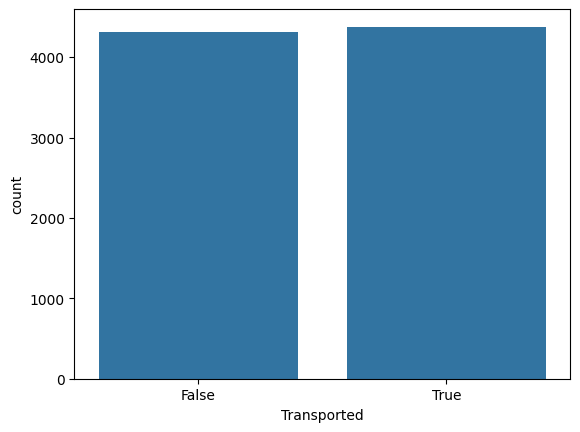

In [5]:
sns.countplot(x='Transported', data=temp)
print(df['Transported'].value_counts())

CryoSleep
False    5439
True     3037
Name: count, dtype: int64


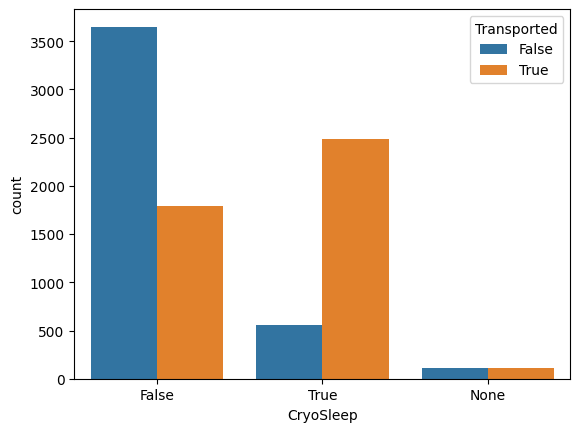

In [6]:
sns.countplot(x='CryoSleep',hue='Transported', data=temp)
print(df['CryoSleep'].value_counts())

<Axes: xlabel='Side', ylabel='count'>

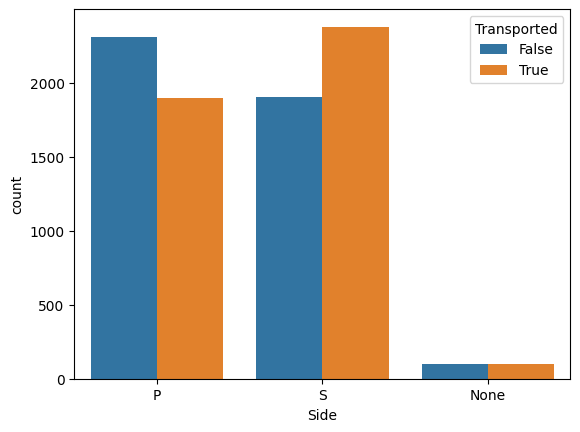

In [7]:
sns.countplot(x='Side',hue='Transported', data=temp)

<Axes: xlabel='Destination', ylabel='count'>

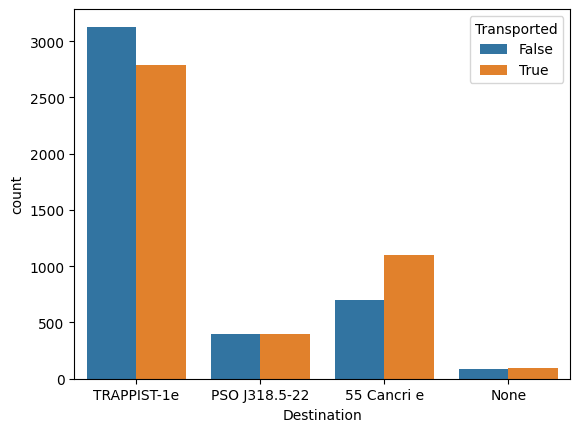

In [8]:
sns.countplot(x='Destination',hue='Transported', data=temp)

<Axes: xlabel='HomePlanet', ylabel='count'>

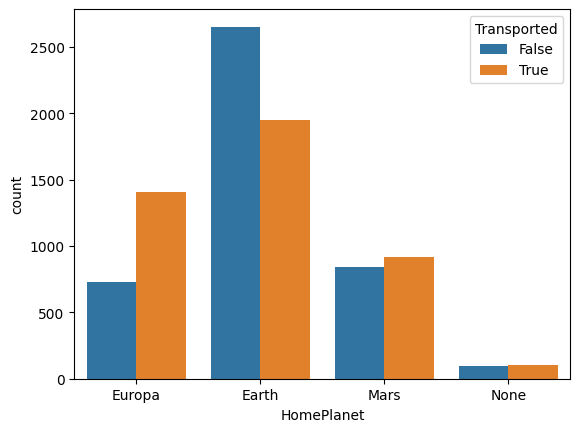

In [9]:
sns.countplot(x='HomePlanet', hue='Transported', data=temp)

<Axes: xlabel='Deck', ylabel='Transported'>

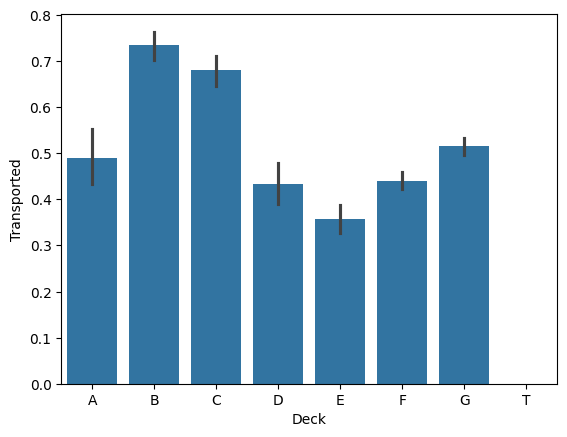

In [10]:
# Заменяем палубу T на A, так как там всего 5 человек
sns.barplot(x='Deck', y='Transported', data=temp, order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])

<Axes: xlabel='Deck_Side', ylabel='count'>

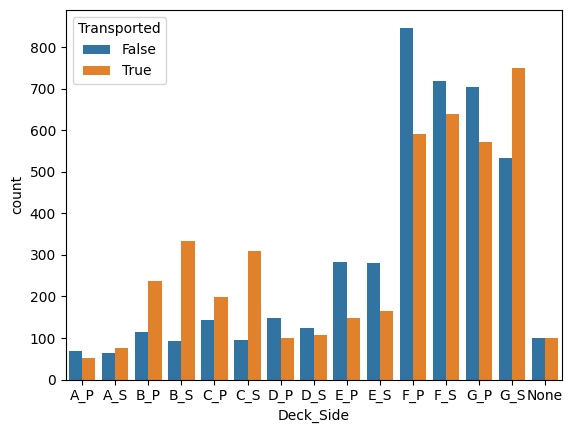

In [11]:
sns.countplot(x='Deck_Side', hue='Transported', data=temp,order=sorted(temp['Deck_Side'].dropna().unique()))

<Axes: xlabel='Age', ylabel='Count'>

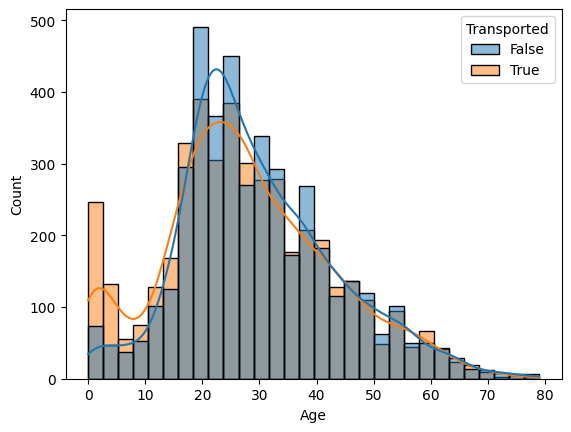

In [12]:
sns.histplot(data=temp, x='Age', hue='Transported', kde=True, bins=30)

<Axes: xlabel='TotalSpend', ylabel='Count'>

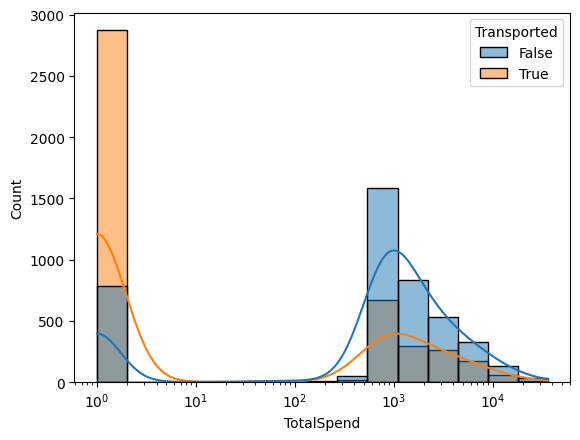

In [13]:
sns.histplot(data=temp, x=temp['TotalSpend'] + 1, hue='Transported', kde=True, log_scale=True)

<Axes: >

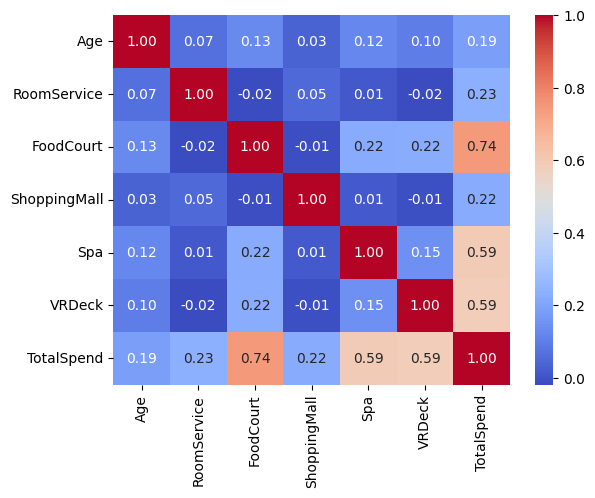

In [14]:
numeric = temp.select_dtypes(include=[np.number])
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f')

In [15]:
def find_best_threshold(y_true, y_proba):
    best_threshold = 0.5
    best_score = 0


    for threshold in np.arange(0.01, 0.7, 0.01):
        preds = (y_proba > threshold).astype(bool)
        score = accuracy_score(y_true, preds)
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
            
    return best_threshold, best_score

In [16]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.metrics import accuracy_score

kf = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []
models = []
holds = []

params = {
    'iterations': 2000,
    'early_stopping_rounds': 50,
    'cat_features': cat_cols,
    'verbose': 200,
    'depth': 7,
    'loss_function': "Logloss",
    'l2_leaf_reg': 20,
    'random_strength': 2.,
    'random_state': 1
}

for train_index, val_index in kf.split(X):

    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    
    model = CatBoostClassifier(**params)
    
    model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold))
    
    val_proba = model.predict_proba(X_val_fold)[:, 1]
    train_proba = model.predict_proba(X_train_fold)[:, 1]
    
    best_threshold, best_acc = find_best_threshold(y_val_fold, val_proba)
    best_train_threshold, best_train_acc = find_best_threshold(y_train_fold, train_proba)
    
    score = accuracy_score(y_val_fold, val_proba > 0.5)
    train_score = accuracy_score(y_train_fold, train_proba > 0.5)
    
    scores.append(best_acc)
    models.append(model)
    holds.append(best_threshold)

    print(f"Точность train (0.5): {train_score}, Best ac: {best_train_acc} th {best_train_threshold}")
    print(f"Точность фолда (0.5): {score}, Best ac: {best_acc} th {best_threshold}")

print(f"\nСредняя точность: {np.mean(scores)}")
print(f"Отклонение: {np.std(scores)}")


0:	learn: 0.6781473	test: 0.6784785	best: 0.6784785 (0)	total: 213ms	remaining: 7m 5s
200:	learn: 0.4100825	test: 0.4205623	best: 0.4205623 (200)	total: 14.1s	remaining: 2m 6s
400:	learn: 0.3822048	test: 0.4042911	best: 0.4042911 (400)	total: 28.9s	remaining: 1m 55s
600:	learn: 0.3644832	test: 0.3992146	best: 0.3992146 (600)	total: 44.6s	remaining: 1m 43s
800:	learn: 0.3498476	test: 0.3973927	best: 0.3972420 (750)	total: 1m 1s	remaining: 1m 31s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3972419996
bestIteration = 750

Shrink model to first 751 iterations.
Точность train (0.5): 0.8507333908541846, Best ac: 0.8520276100086281 th 0.49
Точность фолда (0.5): 0.8142610695802185, Best ac: 0.8154111558366878 th 0.49
0:	learn: 0.6779768	test: 0.6787829	best: 0.6787829 (0)	total: 45.5ms	remaining: 1m 30s
200:	learn: 0.4083871	test: 0.4260341	best: 0.4260341 (200)	total: 14.1s	remaining: 2m 6s
400:	learn: 0.3803478	test: 0.4116810	best: 0.4116810 (400)	total: 29.3s	remain

<BarContainer object of 16 artists>

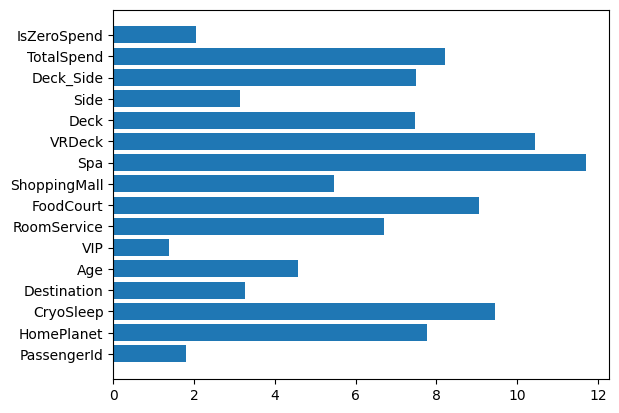

In [17]:
mean_imp = sum(m.get_feature_importance() for m in models) / len(models)
plt.barh(X.columns, mean_imp)

In [59]:
threshold = np.mean(holds)
all_probs = []
for model in models:
    prob = model.predict_proba(X_test)[:, 1]
    all_probs.append(prob)

mean_prob = np.mean(all_probs, axis=0)

y_pred = (mean_prob > threshold).astype(bool)
y_pred = pd.Series(y_pred, name='Transported')

In [60]:
sub = pd.concat([df_test['PassengerId'],y_pred], axis=1)
sub.to_csv('sub.csv', index=False)

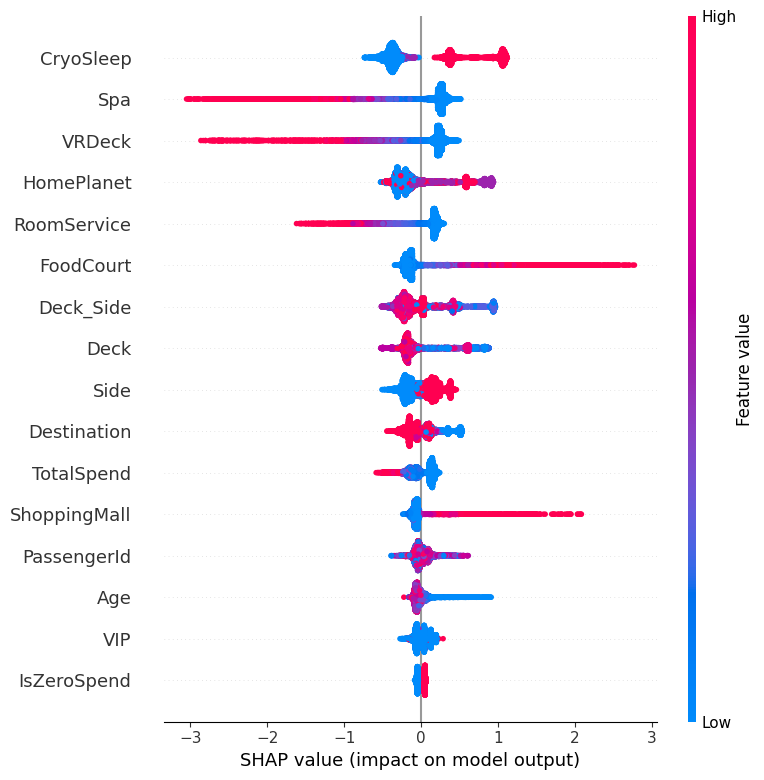

In [20]:
all_shap = []

for model in models:
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X)
    all_shap.append(sv)

mean_shap = np.mean(all_shap, axis=0)

X_plot = X.copy()
le = LabelEncoder()
for col in cat_cols:
    X_plot[col] = le.fit_transform(X_plot[col].astype(str))
shap.summary_plot(mean_shap, X_plot)

In [21]:
for col in ['HomePlanet','Side','IsZeroSpend','VIP','Destination','Deck_Side']:
    le.fit(X[col].astype(str))
    print(f"{col}: {list(le.classes_)}")

HomePlanet: ['Earth', 'Europa', 'Mars', 'None']
Side: ['None', 'P', 'S']
IsZeroSpend: ['0', '1']
VIP: ['False', 'None', 'True']
Destination: ['55 Cancri e', 'None', 'PSO J318.5-22', 'TRAPPIST-1e']
Deck_Side: ['A_P', 'A_S', 'B_P', 'B_S', 'C_P', 'C_S', 'D_P', 'D_S', 'E_P', 'E_S', 'F_P', 'F_S', 'G_P', 'G_S', 'None']


<Figure size 800x500 with 0 Axes>

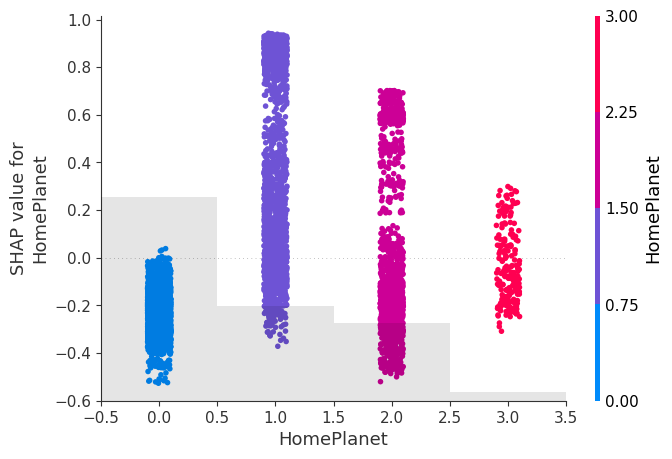

<Figure size 800x500 with 0 Axes>

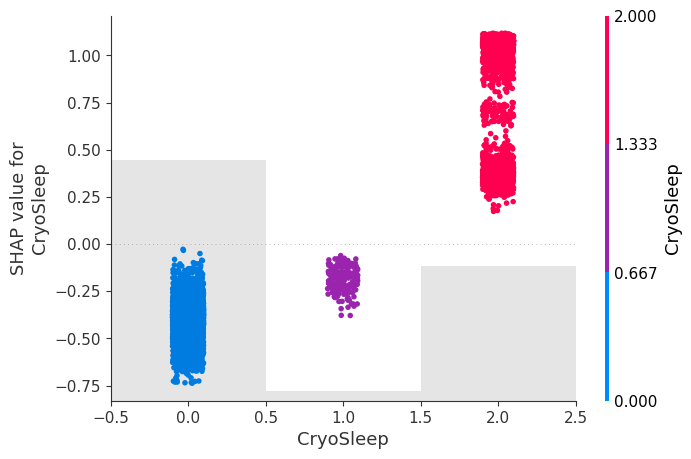

<Figure size 800x500 with 0 Axes>

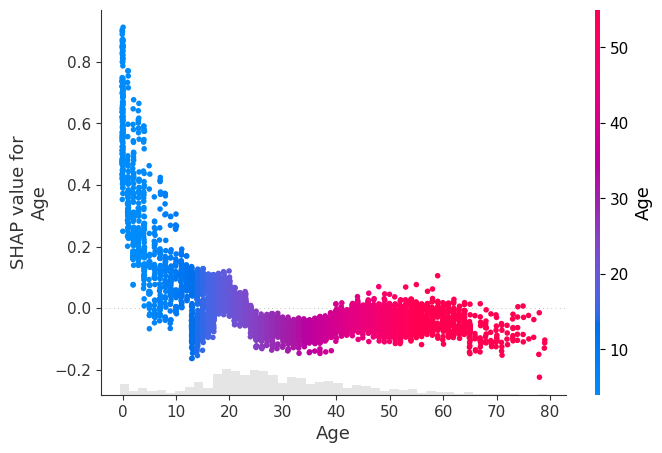

<Figure size 800x500 with 0 Axes>

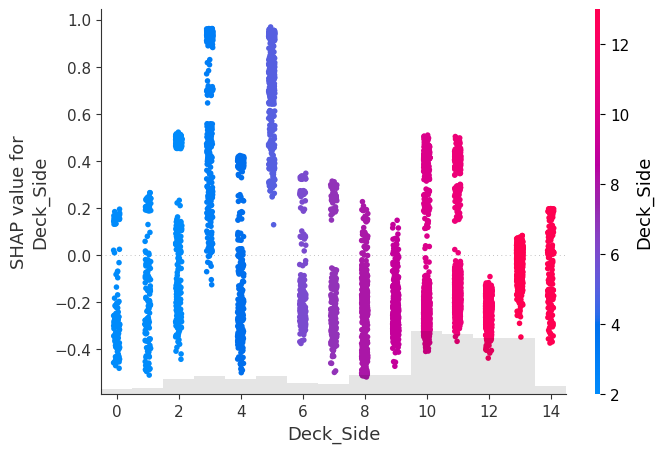

<Figure size 800x500 with 0 Axes>

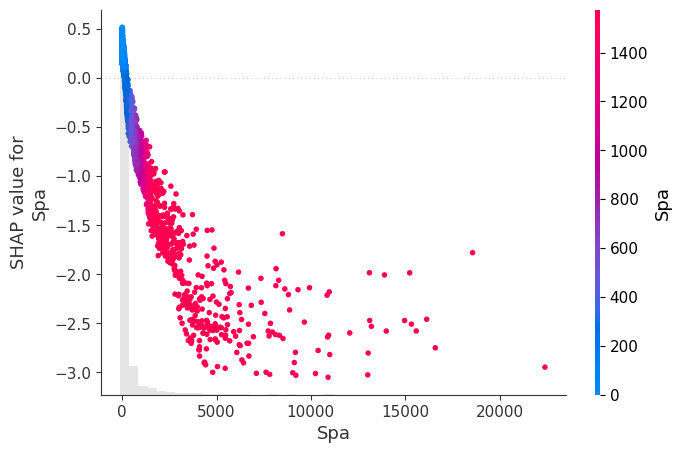

<Figure size 800x500 with 0 Axes>

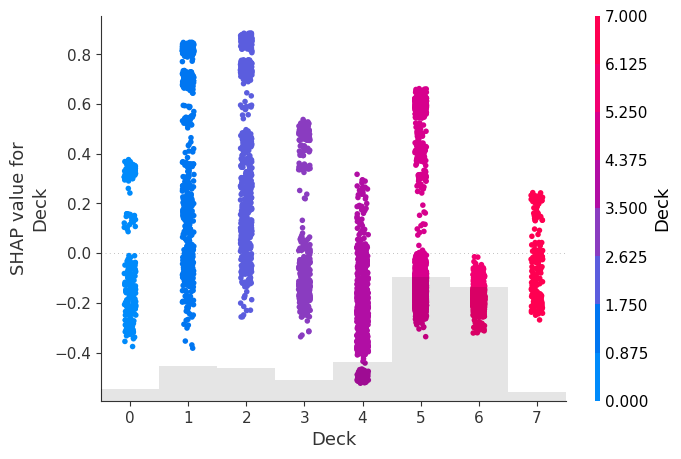

<Figure size 800x500 with 0 Axes>

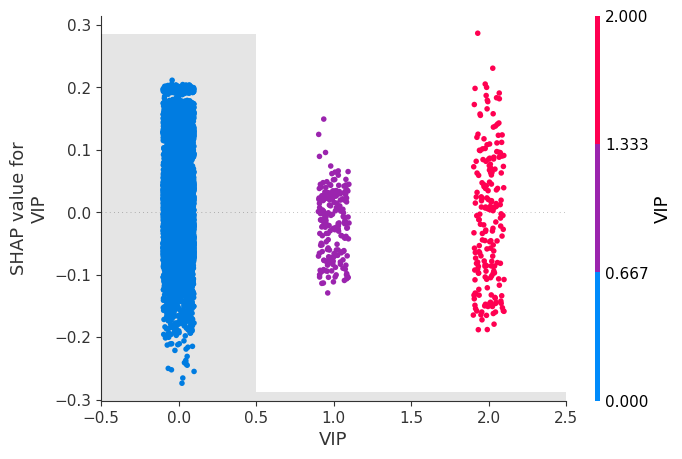

<Figure size 800x500 with 0 Axes>

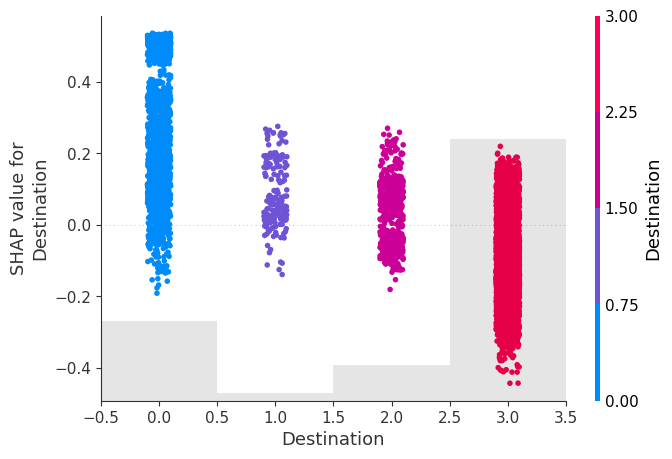

<Figure size 800x500 with 0 Axes>

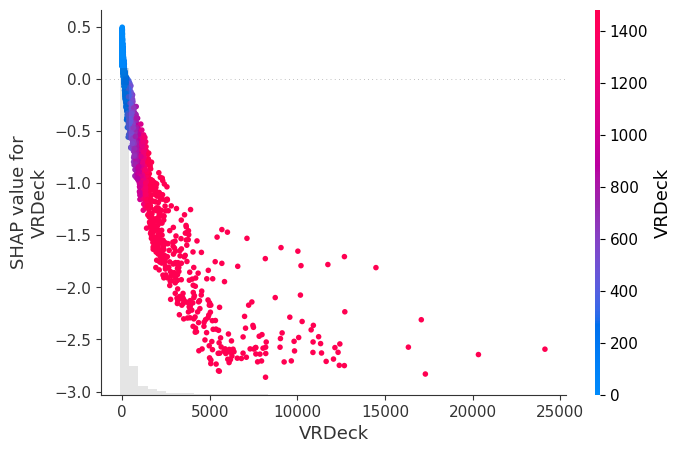

<Figure size 800x500 with 0 Axes>

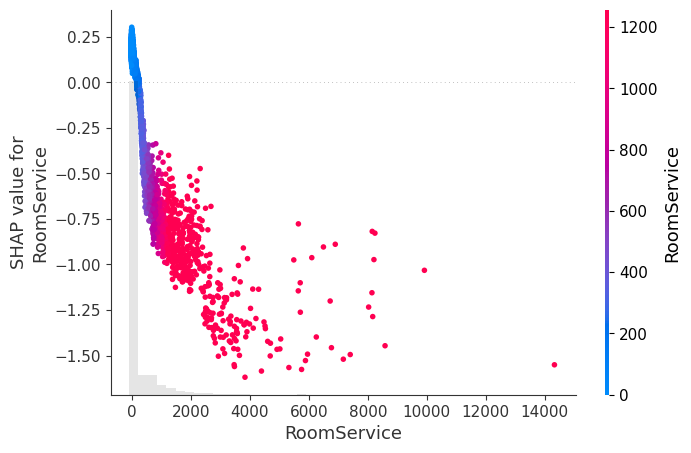

<Figure size 800x500 with 0 Axes>

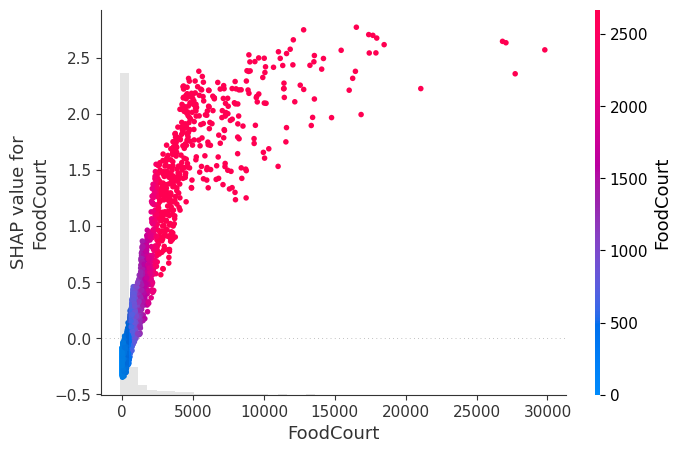

<Figure size 800x500 with 0 Axes>

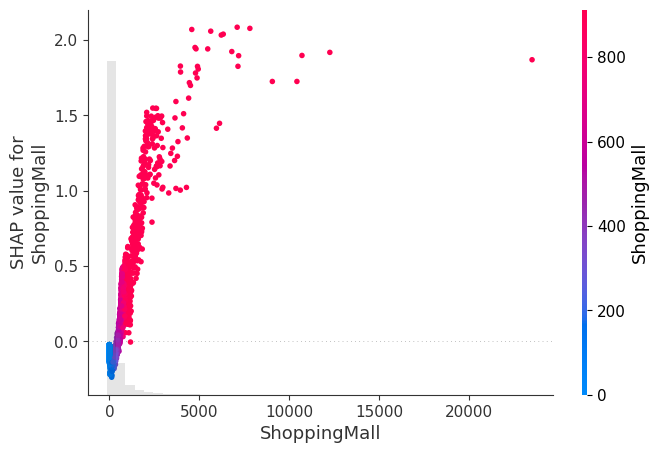

<Figure size 800x500 with 0 Axes>

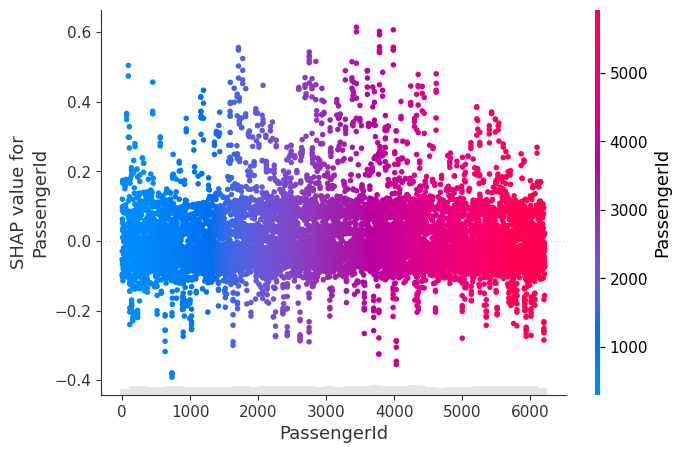

In [22]:
shap_exp = shap.Explanation(values=mean_shap, 
                            data=X_plot.values, 
                            feature_names=X_plot.columns)
features_to_plot = ['HomePlanet', 'CryoSleep', 'Age', 'Deck_Side', 'Spa', 'Deck', 'VIP', 'Destination',
                    'VRDeck','RoomService', 'FoodCourt', 'ShoppingMall','PassengerId']

for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    shap.plots.scatter(shap_exp[:, col], color=shap_exp[:, col])

<Axes: xlabel='Service', ylabel='Usage'>

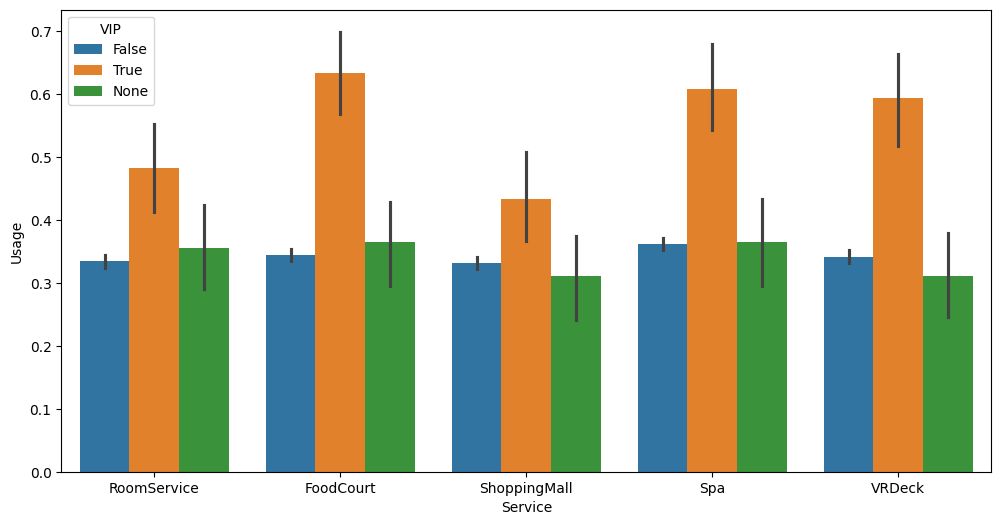

In [23]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

use_df = (X[spend_cols] > 0).astype(int)
use_df['VIP'] = X['VIP']

melted_use = use_df.melt(id_vars='VIP', var_name='Service', value_name='Usage')

plt.figure(figsize=(12, 6))
sns.barplot(x='Service', y='Usage', hue='VIP', data=melted_use)

<Axes: xlabel='Age', ylabel='Count'>

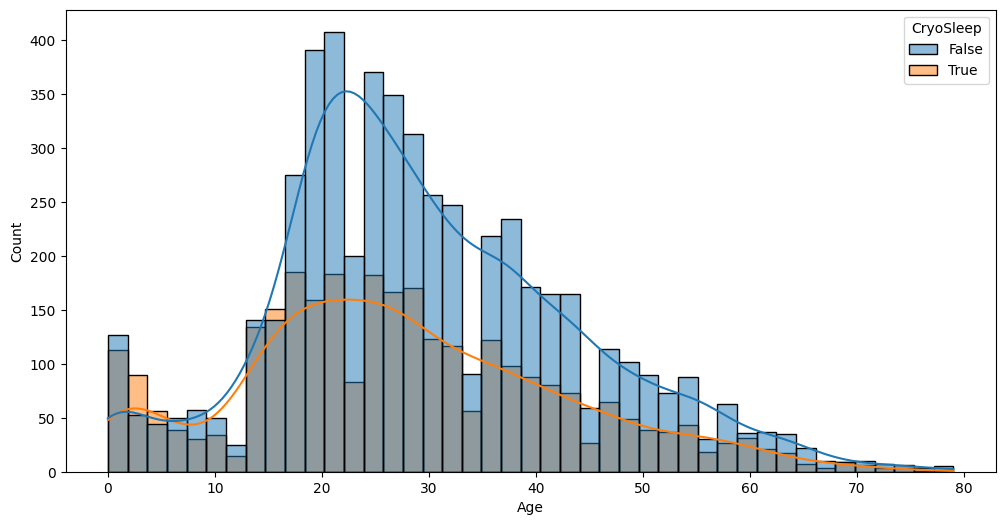

In [24]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='Age', hue='CryoSleep', kde=True)

In [25]:
summary = pd.crosstab(X['Deck_Side'], X['CryoSleep'])
print(summary)

CryoSleep  False  None  True
Deck_Side                   
A_P           89     3    29
A_S           97     4    39
B_P          161     8   184
B_S          180    11   235
C_P          202     9   130
C_S          228    14   164
D_P          195     7    46
D_S          169     3    58
E_P          341    13    75
E_S          347     7    93
F_P         1118    41   279
F_S         1058    27   271
G_P          567    32   677
G_S          579    31   673
None         108     7    84


<Figure size 800x500 with 0 Axes>

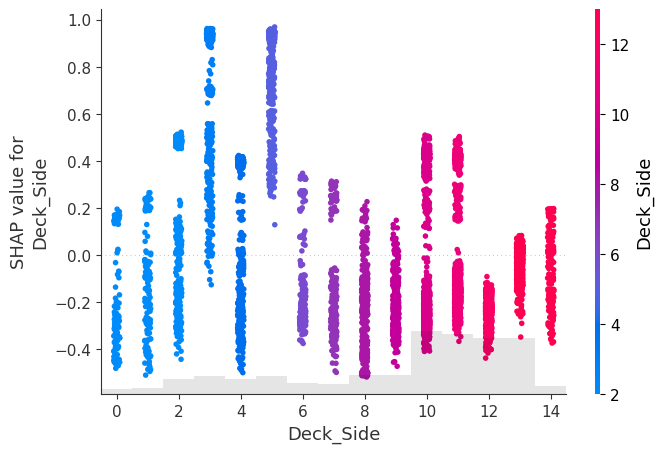

In [26]:
plt.figure(figsize=(8, 5))
shap.plots.scatter(shap_exp[:, 'Deck_Side'], color=shap_exp[:, 'Deck_Side'])

<Axes: xlabel='Deck_Side', ylabel='count'>

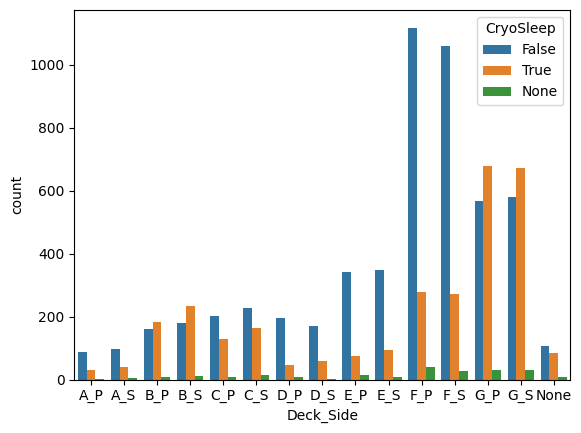

In [27]:
sns.countplot(data=temp, x='Deck_Side', hue='CryoSleep',order=sorted(temp['Deck_Side'].dropna().unique()))

<Axes: xlabel='Deck_Side', ylabel='count'>

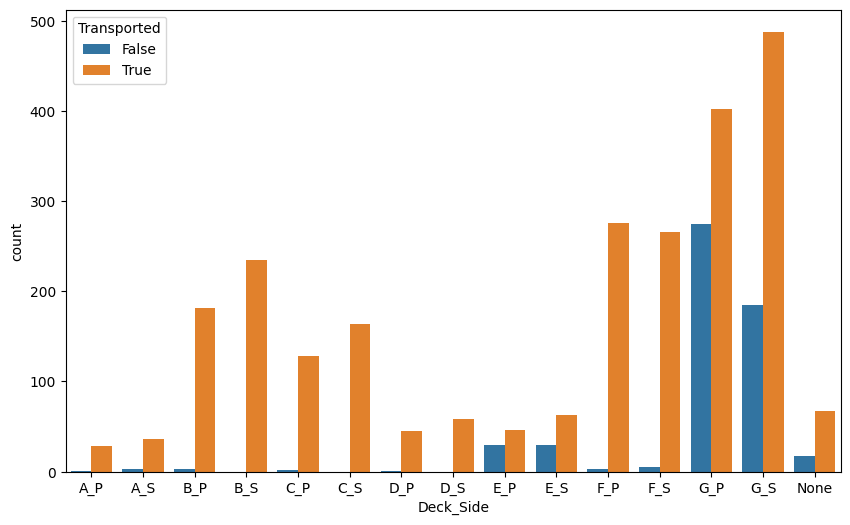

In [28]:

plt.figure(figsize=(10, 6))
sns.countplot(data=temp[temp['CryoSleep'] == 'True'], x='Deck_Side', hue='Transported',order=sorted(temp['Deck_Side'].dropna().unique()))

<Axes: xlabel='Deck', ylabel='TotalSpend'>

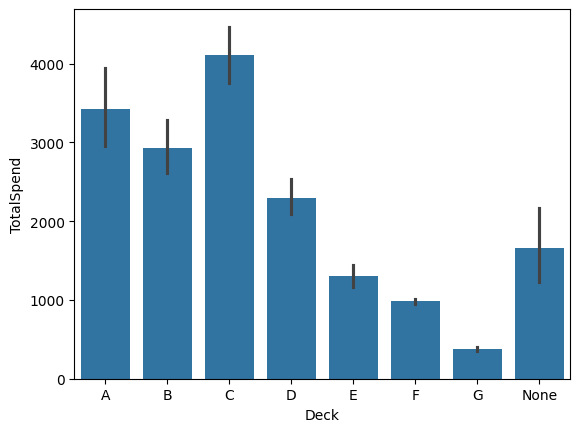

In [29]:
sns.barplot(data=temp, x='Deck', y='TotalSpend', 
            order=sorted(temp['Deck'].dropna().unique()))

Deck
A        261
B        779
C        747
D        478
E        876
F       2794
G       2559
None     199
Name: count, dtype: int64


<Axes: xlabel='Deck', ylabel='count'>

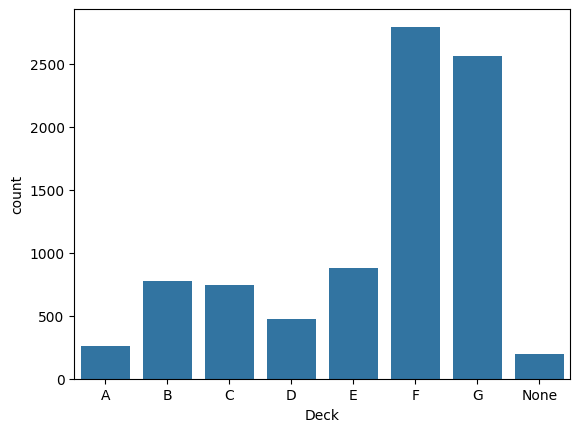

In [30]:
print(temp['Deck'].value_counts().sort_index())
sns.countplot(data=temp, x='Deck', 
              order=sorted(temp['Deck'].dropna().unique()))

<Axes: xlabel='Deck', ylabel='count'>

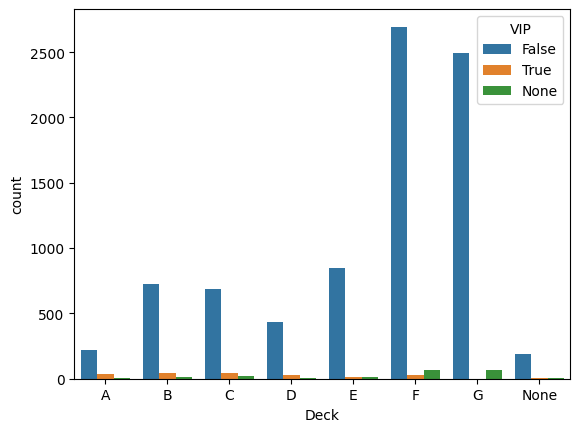

In [31]:
sns.countplot(data=temp, x='Deck', hue='VIP', 
              order=sorted(temp['Deck'].dropna().unique()))

In [32]:
vip_counts = temp[temp['VIP'] == 'True']['Deck'].value_counts().sort_index()
print(vip_counts)

Deck
A       35
B       42
C       41
D       31
E       15
F       29
None     6
Name: count, dtype: int64


<Axes: xlabel='Deck_Side', ylabel='Average_Spend'>

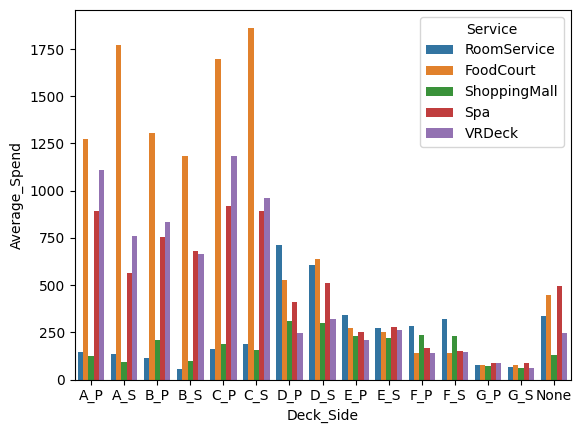

In [33]:
deck_spending = temp.groupby('Deck_Side')[spend_cols].mean()

deck_spending_long = deck_spending.reset_index().melt(id_vars='Deck_Side', 
                                                       var_name='Service', 
                                                       value_name='Average_Spend')


sns.barplot(data=deck_spending_long, x='Deck_Side', y='Average_Spend', hue='Service', 
            order=sorted(temp['Deck_Side'].dropna().unique()))

<Axes: xlabel='Age', ylabel='RoomService'>

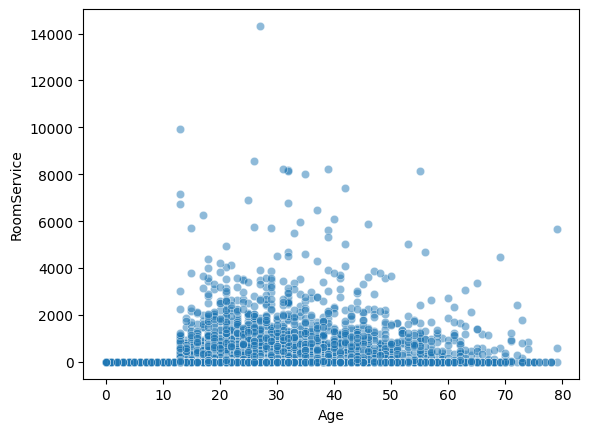

In [34]:
sns.scatterplot(data=df, x='Age', y=spend_cols[0], alpha=0.5)

<Axes: xlabel='Age', ylabel='FoodCourt'>

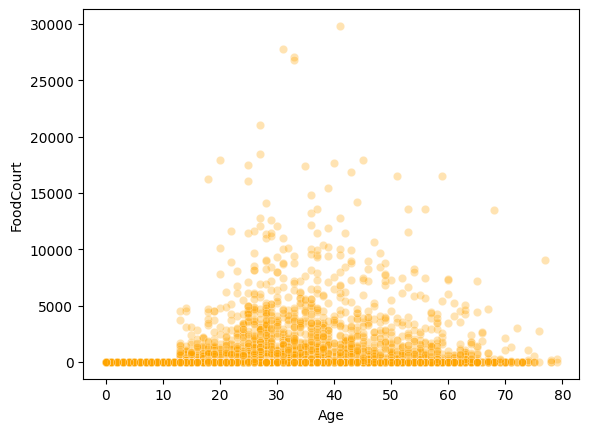

In [35]:
sns.scatterplot(data=df, x='Age', y=spend_cols[1], alpha=0.3, color='orange')

<Axes: xlabel='Age', ylabel='ShoppingMall'>

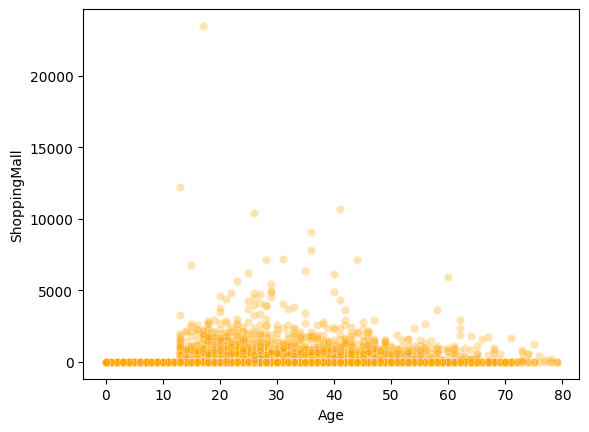

In [36]:
sns.scatterplot(data=df, x='Age', y=spend_cols[2], alpha=0.3, color='orange')

<Axes: xlabel='Age', ylabel='Spa'>

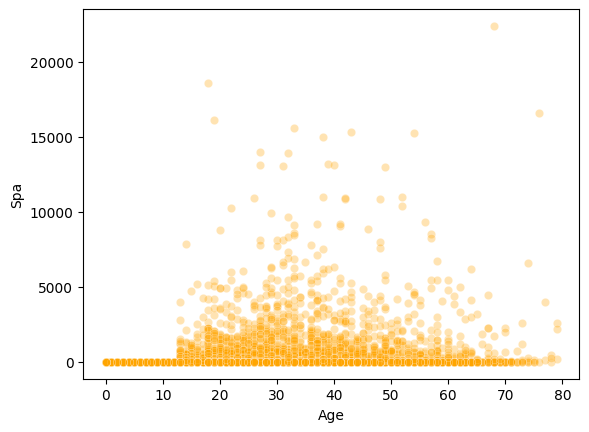

In [37]:
sns.scatterplot(data=df, x='Age', y=spend_cols[3], alpha=0.3, color='orange')

<Axes: xlabel='Age', ylabel='VRDeck'>

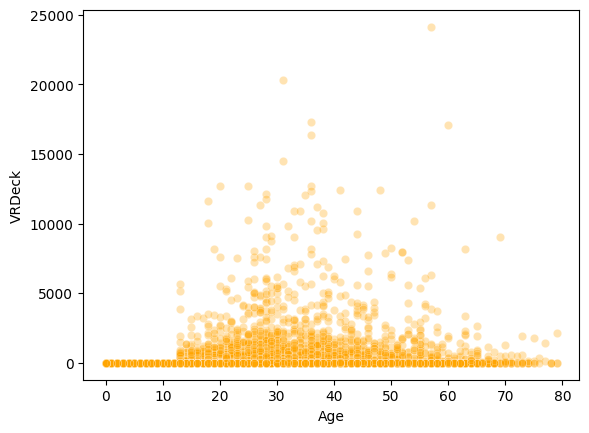

In [38]:
sns.scatterplot(data=df, x='Age', y=spend_cols[4], alpha=0.3, color='orange')

<Axes: xlabel='HomePlanet', ylabel='RoomService'>

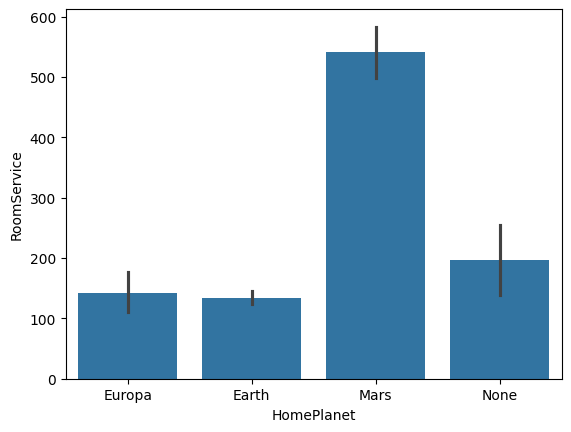

In [39]:
sns.barplot(data=temp, x='HomePlanet', y=spend_cols[0])

<Axes: xlabel='HomePlanet', ylabel='FoodCourt'>

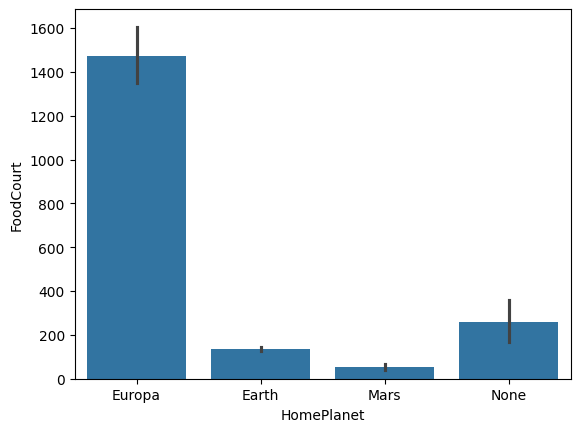

In [40]:
sns.barplot(data=temp, x='HomePlanet', y=spend_cols[1])

<Axes: xlabel='HomePlanet', ylabel='ShoppingMall'>

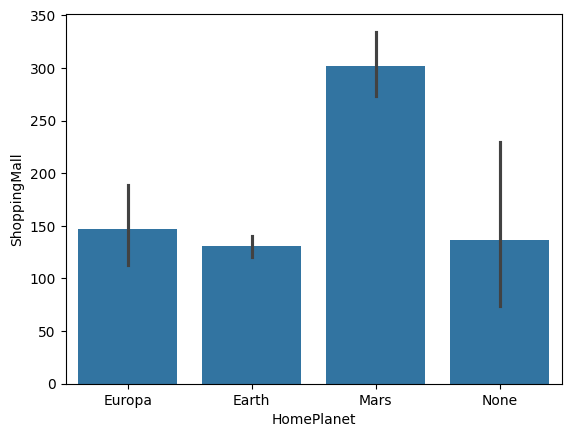

In [41]:
sns.barplot(data=temp, x='HomePlanet', y=spend_cols[2])

<Axes: xlabel='HomePlanet', ylabel='Spa'>

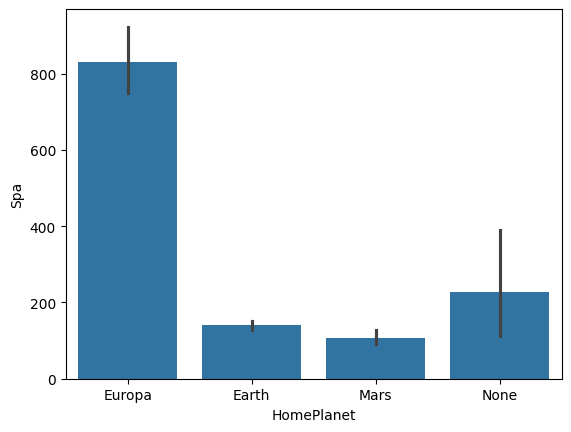

In [42]:
sns.barplot(data=temp, x='HomePlanet', y=spend_cols[3])

<Axes: xlabel='HomePlanet', ylabel='VRDeck'>

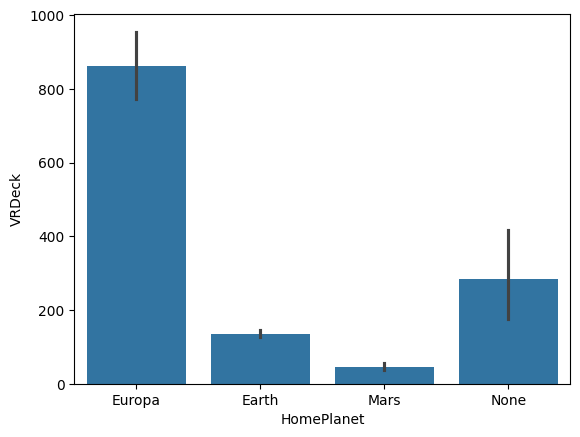

In [43]:
sns.barplot(data=temp, x='HomePlanet', y=spend_cols[4])

<Axes: xlabel='HomePlanet', ylabel='count'>

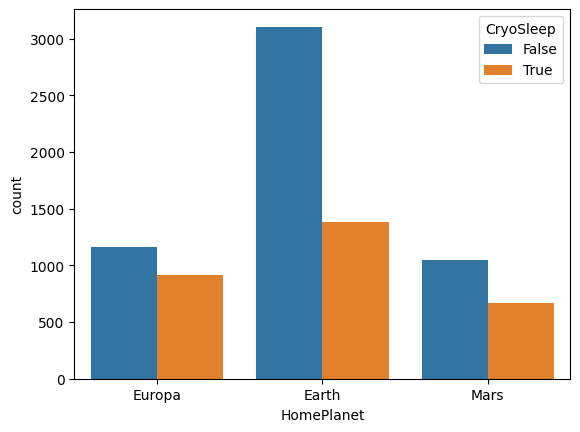

In [44]:
sns.countplot(data=df, x='HomePlanet', hue='CryoSleep')

<Axes: xlabel='HomePlanet', ylabel='count'>

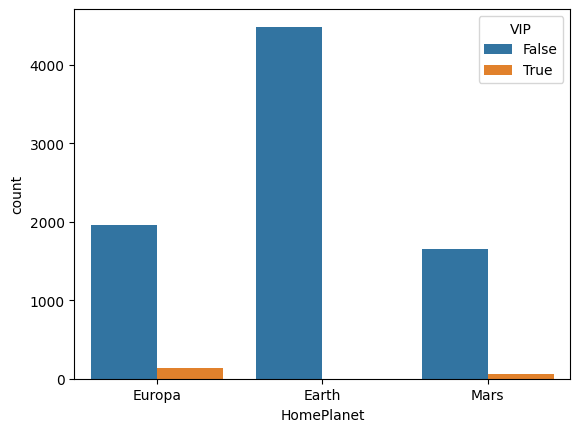

In [45]:
sns.countplot(data=df, x='HomePlanet', hue='VIP')

<Axes: xlabel='HomePlanet', ylabel='Deck'>

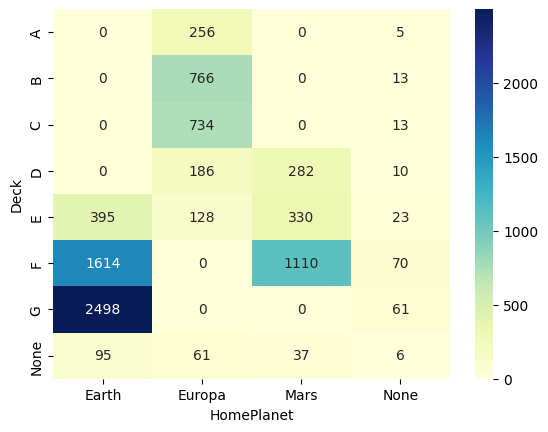

In [46]:
planet_on_deck = pd.crosstab(temp['Deck'], temp['HomePlanet'])
sns.heatmap(planet_on_deck, annot=True, fmt='d', cmap='YlGnBu')

<Axes: xlabel='HomePlanet', ylabel='TotalSpend'>

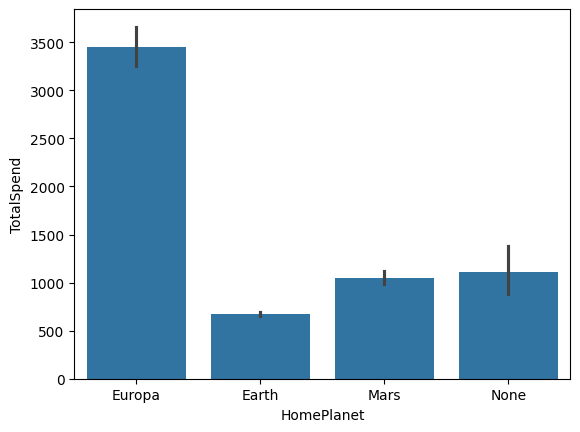

In [47]:
sns.barplot(data=temp, x='HomePlanet', y='TotalSpend')

<Axes: xlabel='Destination', ylabel='count'>

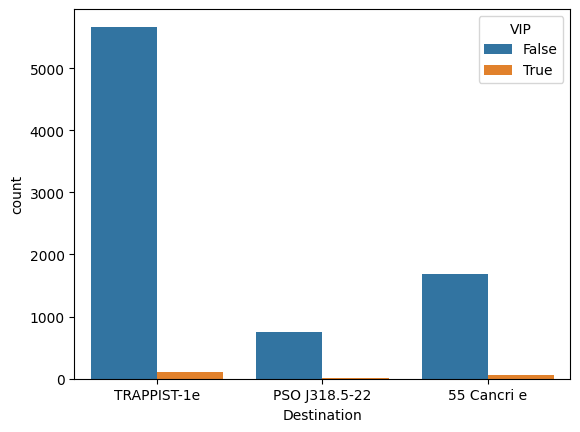

In [48]:
sns.countplot(data=df, x='Destination', hue='VIP')

<Axes: xlabel='Destination', ylabel='TotalSpend'>

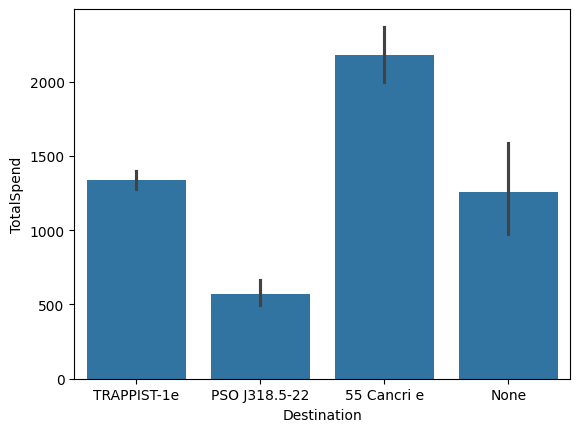

In [49]:
sns.barplot(data=temp, x='Destination', y='TotalSpend')

<Axes: xlabel='Destination', ylabel='Deck'>

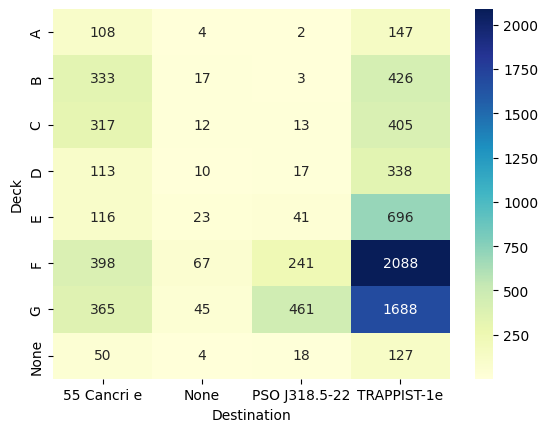

In [50]:
travel_planet_on_deck = pd.crosstab(temp['Deck'], temp['Destination'])
sns.heatmap(travel_planet_on_deck, annot=True, fmt='d', cmap='YlGnBu')

<Axes: xlabel='Destination', ylabel='count'>

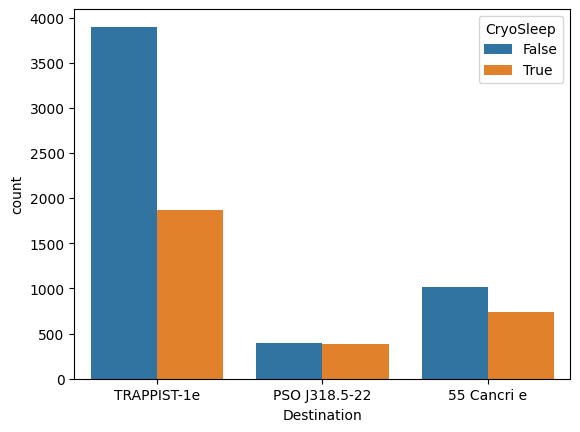

In [51]:
sns.countplot(data=df, x='Destination', hue='CryoSleep')

<Axes: xlabel='Transported', ylabel='count'>

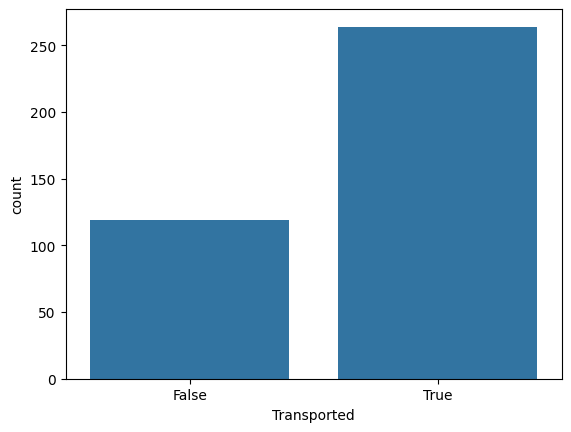

In [52]:
pso_cryo_all = df[(df['CryoSleep'] == True) & (df['Destination'] == 'PSO J318.5-22')]
sns.countplot(data=pso_cryo_all, x='Transported')

<Axes: xlabel='Transported', ylabel='count'>

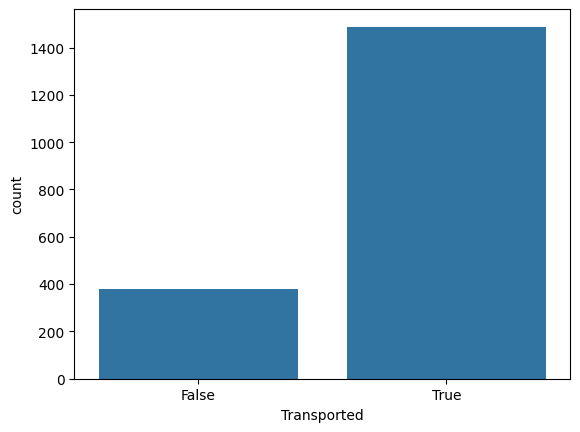

In [53]:
pso_cryo_all = df[(df['CryoSleep'] == True) & (df['Destination'] == 'TRAPPIST-1e')]
sns.countplot(data=pso_cryo_all, x='Transported')

<Axes: xlabel='Transported', ylabel='count'>

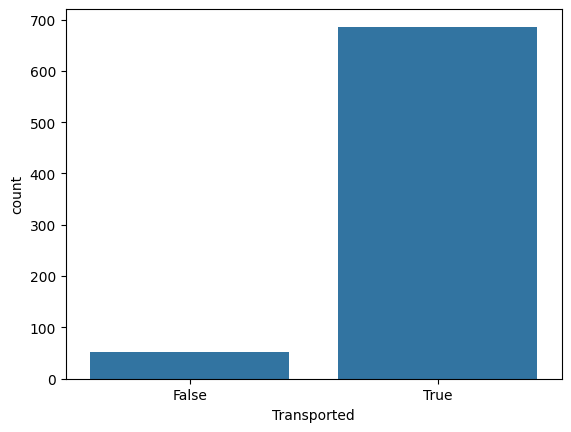

In [54]:
pso_cryo_all = df[(df['CryoSleep'] == True) & (df['Destination'] == '55 Cancri e')]
sns.countplot(data=pso_cryo_all, x='Transported')

<Axes: xlabel='Destination', ylabel='RoomService'>

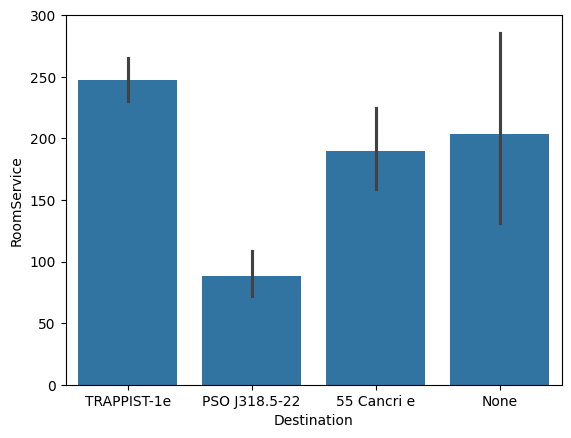

In [55]:
sns.barplot(data=temp, x='Destination', y=spend_cols[0])

<Axes: xlabel='Destination', ylabel='FoodCourt'>

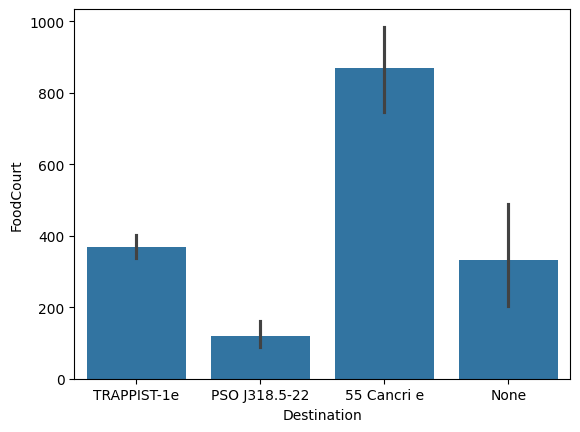

In [56]:
sns.barplot(data=temp, x='Destination', y=spend_cols[1])